## MCMC Fitting

In [1]:
import sys
sys.path.append("/global/homes/z/zzhang13/DESI/Projection")
from setup import *

from tools.notebook_setup import *
from tools.projection_functions import *
from richness_relation.richness_trend_analysis import *


LF_WEIGHTED_SPEC_CATALOG = "bgs_clus_RM_gal_matched_with_spec_richness_lfweighted.pickle"
LAMBDA_SPEC_COL = "lambda_spec_noproj_weighted"
LAMBDA_SPEC_TOT_COL = "lambda_spec_proj_weighted"

bgs_matched, zbin, lmda_bins, z_bins = prepare_default_richness_inputs(
    catalog_filename=LF_WEIGHTED_SPEC_CATALOG,
)

required_cols = ["LF_WEIGHT", LAMBDA_SPEC_COL, LAMBDA_SPEC_TOT_COL]
missing_cols = [col for col in required_cols if col not in bgs_matched.colnames]
if missing_cols:
    raise KeyError(
        f"The input catalog is missing {missing_cols}. Run "
        "make_catalogs/projection_match_catalogs.py to create LF-weighted spectroscopic richness columns, then reload this notebook."
    )

print(f"Using catalog: {LF_WEIGHTED_SPEC_CATALOG}")
print("LF_WEIGHT percentiles:", np.nanpercentile(np.asarray(bgs_matched["LF_WEIGHT"], dtype=float), [0, 16, 50, 84, 100]))
print("lambda_spec_lfweighted percentiles:", np.nanpercentile(np.asarray(bgs_matched[LAMBDA_SPEC_COL], dtype=float), [0, 16, 50, 84, 100]))

binBoundaries = zbin.bin_boundaries
binCent = zbin.bin_centers
bin_width = zbin.bin_widths
micro_bin = zbin.micro_bin_boundaries
binCent_micro = zbin.micro_bin_centers


100%|██████████| 8000/8000 [00:26<00:00, 305.78it/s]



Redshift bin: 0.1 < z < 0.2

Model: loglinear
alpha            = 1.8460 -0.0159 +0.0159
beta             = 0.8816 -0.0728 +0.0746
log_sigma_int    = -5.8009 -1.4998 +1.5858
Fit statistics:
chi2                : 4.6045
dof                 : 5.0000
reduced_chi2        : 0.9209
p_value             : 0.4660
aic                 : -26.5802
bic                 : -26.3419
sigma_int_dex       : 0.0004
residual_mean_dex   : 0.0017
residual_std_dex    : 0.0407

Model: broken_loglinear
alpha            = 1.8205 -0.1016 +0.0264
beta_low         = 0.7598 -0.3791 +0.1214
beta_high        = 1.4313 -0.4877 +1.7516
x_break          = 1.7890 -0.3690 +0.1068
log_sigma_int    = -5.9119 -1.4265 +1.5602
Fit statistics:
chi2                : 0.8965
dof                 : 3.0000
reduced_chi2        : 0.2988
p_value             : 0.8263
aic                 : -26.2832
bic                 : -25.8860
sigma_int_dex       : 0.0009
residual_mean_dex   : 0.0006
residual_std_dex    : 0.0108

Model comparison:
Delta AIC

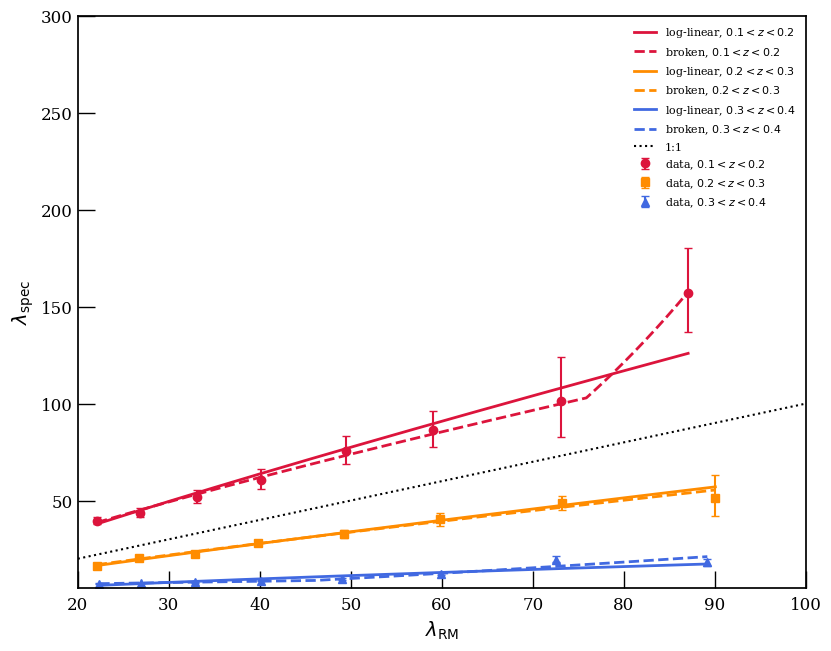

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
from scipy.stats import chi2

# ------------------------------------------------------------
# 1. Build binned log-mean data from precomputed LF-weighted richnesses
# ------------------------------------------------------------

from astropy.table import unique

table = bgs_matched

redmapper_col = "LAMBDA"
id_col = "ID"
z_col = "Z_SPEC_x"
lambda_spec_col = LAMBDA_SPEC_COL

z_bins = [[0.1, 0.2], [0.2, 0.3], [0.3, 0.4]]
rm_trend_bins = np.logspace(np.log10(20), np.log10(100), 9)

# The matched catalog has one row per BGS galaxy, while the precomputed
# lambda_spec value is a cluster-level quantity copied onto each row.
# Collapse to one row per cluster before making trends.
cluster_table = unique(table, keys=id_col)

redmapper_values = np.asarray(cluster_table[redmapper_col], dtype=float)
z_values = np.asarray(cluster_table[z_col], dtype=float)
lambda_spec_values = np.asarray(cluster_table[lambda_spec_col], dtype=float)

fit_data = {}

for zlo, zhi in z_bins:
    zmask = (z_values >= zlo) & (z_values < zhi)

    x_log = []
    y_log = []
    y_log_sem = []
    n_per_bin = []

    for lo, hi in zip(rm_trend_bins[:-1], rm_trend_bins[1:]):
        mask = (
            zmask
            & (redmapper_values >= lo)
            & (redmapper_values < hi)
            & np.isfinite(redmapper_values)
            & np.isfinite(lambda_spec_values)
            & (redmapper_values > 0)
            & (lambda_spec_values > 0)
        )

        lambda_rm_ind = redmapper_values[mask]
        lambda_spec_ind = lambda_spec_values[mask]

        if len(lambda_spec_ind) <= 1:
            continue

        log_rm = np.log10(lambda_rm_ind)
        log_spec = np.log10(lambda_spec_ind)

        x_log.append(np.nanmean(log_rm))
        y_log.append(np.nanmean(log_spec))
        y_log_sem.append(np.nanstd(log_spec, ddof=1) / np.sqrt(len(log_spec)))
        n_per_bin.append(len(log_spec))

    fit_data[(zlo, zhi)] = {
        "x": np.asarray(x_log, dtype=float),
        "y": np.asarray(y_log, dtype=float),
        "yerr": np.asarray(y_log_sem, dtype=float),
        "n": np.asarray(n_per_bin, dtype=int),
    }


# ------------------------------------------------------------
# 2. Define models
# ------------------------------------------------------------

def loglinear_model(theta, x, x_pivot):
    alpha, beta, log_sigma_int = theta
    return alpha + beta * (x - x_pivot)


def broken_loglinear_model(theta, x, x_pivot):
    alpha, beta_low, beta_high, x_break, log_sigma_int = theta
    return (
        alpha
        + beta_low * (x - x_pivot)
        + (beta_high - beta_low) * np.maximum(0.0, x - x_break)
    )


def model_slope(theta, x, model_name):
    if model_name == "loglinear":
        return np.full_like(x, theta[1], dtype=float)

    beta_low = theta[1]
    beta_high = theta[2]
    x_break = theta[3]

    return np.where(x < x_break, beta_low, beta_high)


# ------------------------------------------------------------
# 3. Priors and likelihoods
# ------------------------------------------------------------

def log_prior(theta, x, model_name):
    if model_name == "loglinear":
        alpha, beta, log_sigma_int = theta

        if not (0.0 < alpha < 3.0):
            return -np.inf
        if not (-5.0 < beta < 5.0):
            return -np.inf
        if not (-8.0 < log_sigma_int < 1.0):
            return -np.inf

        return 0.0

    if model_name == "broken_loglinear":
        alpha, beta_low, beta_high, x_break, log_sigma_int = theta

        if not (0.0 < alpha < 3.0):
            return -np.inf
        if not (-5.0 < beta_low < 5.0):
            return -np.inf
        if not (-5.0 < beta_high < 5.0):
            return -np.inf
        if not (np.nanmin(x) < x_break < np.nanmax(x)):
            return -np.inf
        if not (-8.0 < log_sigma_int < 1.0):
            return -np.inf

        return 0.0

    raise ValueError(f"Unknown model_name: {model_name}")


def log_likelihood(theta, x, y, yerr, model_name, x_pivot):
    if model_name == "loglinear":
        y_model = loglinear_model(theta, x, x_pivot)
    elif model_name == "broken_loglinear":
        y_model = broken_loglinear_model(theta, x, x_pivot)
    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    sigma_int = np.exp(theta[-1])
    sigma2 = yerr**2 + sigma_int**2

    return -0.5 * np.sum(
        (y - y_model) ** 2 / sigma2
        + np.log(2.0 * np.pi * sigma2)
    )


def log_probability(theta, x, y, yerr, model_name, x_pivot):
    lp = log_prior(theta, x, model_name)

    if not np.isfinite(lp):
        return -np.inf

    return lp + log_likelihood(theta, x, y, yerr, model_name, x_pivot)


# ------------------------------------------------------------
# 4. MCMC runner
# ------------------------------------------------------------

def initial_guess(x, y, yerr, model_name):
    x_pivot = np.nanmedian(x)

    good = np.isfinite(x) & np.isfinite(y) & np.isfinite(yerr) & (yerr > 0)

    slope, intercept = np.polyfit(x[good] - x_pivot, y[good], deg=1)
    residual = y[good] - (intercept + slope * (x[good] - x_pivot))
    sigma_int = max(np.nanstd(residual), 0.03)

    if model_name == "loglinear":
        return np.array([intercept, slope, np.log(sigma_int)])

    if model_name == "broken_loglinear":
        return np.array([
            intercept,
            slope,
            slope,
            np.nanmedian(x[good]),
            np.log(sigma_int),
        ])

    raise ValueError(f"Unknown model_name: {model_name}")


def run_mcmc_fit(
    x,
    y,
    yerr,
    model_name,
    nwalkers=64,
    nsteps=6000,
    burn=1500,
    thin=5,
    seed=123,
):
    rng = np.random.default_rng(seed)

    good = (
        np.isfinite(x)
        & np.isfinite(y)
        & np.isfinite(yerr)
        & (yerr > 0)
    )

    x = x[good]
    y = y[good]
    yerr = yerr[good]

    if model_name == "loglinear" and len(x) < 3:
        raise ValueError("Need at least 3 valid points for log-linear fit.")

    if model_name == "broken_loglinear" and len(x) < 6:
        raise ValueError("Need at least 6 valid points for broken log-linear fit.")

    x_pivot = np.nanmedian(x)
    p_init = initial_guess(x, y, yerr, model_name)
    ndim = len(p_init)

    p0 = p_init + 1e-3 * rng.normal(size=(nwalkers, ndim))

    if model_name == "broken_loglinear":
        p0[:, 3] = rng.uniform(np.nanmin(x), np.nanmax(x), size=nwalkers)

    sampler = emcee.EnsembleSampler(
        nwalkers,
        ndim,
        log_probability,
        args=(x, y, yerr, model_name, x_pivot),
    )

    sampler.run_mcmc(p0, nsteps, progress=True)

    samples = sampler.get_chain(discard=burn, thin=thin, flat=True)
    log_prob = sampler.get_log_prob(discard=burn, thin=thin, flat=True)

    best = samples[np.argmax(log_prob)]

    stats = compute_fit_stats(best, x, y, yerr, model_name, x_pivot)

    return {
        "model_name": model_name,
        "x": x,
        "y": y,
        "yerr": yerr,
        "x_pivot": x_pivot,
        "samples": samples,
        "best": best,
        "stats": stats,
    }


# ------------------------------------------------------------
# 5. Fit statistics
# ------------------------------------------------------------

def predict_model(theta, x, model_name, x_pivot):
    if model_name == "loglinear":
        return loglinear_model(theta, x, x_pivot)
    if model_name == "broken_loglinear":
        return broken_loglinear_model(theta, x, x_pivot)
    raise ValueError(f"Unknown model_name: {model_name}")


def compute_fit_stats(theta, x, y, yerr, model_name, x_pivot):
    y_model = predict_model(theta, x, model_name, x_pivot)

    sigma_int = np.exp(theta[-1])
    sigma2 = yerr**2 + sigma_int**2

    residual = y - y_model

    chi2_val = np.sum(residual**2 / sigma2)
    n = len(x)
    k = len(theta)
    dof = max(n - k, 1)

    loglike = log_likelihood(theta, x, y, yerr, model_name, x_pivot)

    aic = 2 * k - 2 * loglike
    bic = k * np.log(n) - 2 * loglike

    p_value = chi2.sf(chi2_val, dof)

    return {
        "chi2": chi2_val,
        "dof": dof,
        "reduced_chi2": chi2_val / dof,
        "p_value": p_value,
        "aic": aic,
        "bic": bic,
        "sigma_int_dex": sigma_int,
        "residual_mean_dex": np.nanmean(residual),
        "residual_std_dex": np.nanstd(residual, ddof=1),
    }


def summarize_samples(samples, names):
    summary = {}

    for i, name in enumerate(names):
        q16, q50, q84 = np.nanpercentile(samples[:, i], [16, 50, 84])
        summary[name] = {
            "median": q50,
            "minus": q50 - q16,
            "plus": q84 - q50,
        }

    return summary


# ------------------------------------------------------------
# 6. Run fits
# ------------------------------------------------------------

fit_results = {}

for zbin, data in fit_data.items():
    x = data["x"]
    y = data["y"]
    yerr = data["yerr"]

    fit_results[zbin] = {}

    fit_results[zbin]["loglinear"] = run_mcmc_fit(
        x,
        y,
        yerr,
        model_name="loglinear",
        nwalkers=64,
        nsteps=6000,
        burn=1500,
        thin=5,
        seed=123,
    )

    # Broken model only if enough binned points exist.
    if np.sum(np.isfinite(x) & np.isfinite(y) & np.isfinite(yerr) & (yerr > 0)) >= 6:
        fit_results[zbin]["broken_loglinear"] = run_mcmc_fit(
            x,
            y,
            yerr,
            model_name="broken_loglinear",
            nwalkers=80,
            nsteps=8000,
            burn=2000,
            thin=5,
            seed=456,
        )


# ------------------------------------------------------------
# 7. Print summaries
# ------------------------------------------------------------

for zbin, results in fit_results.items():
    print("\n" + "=" * 72)
    print(f"Redshift bin: {zbin[0]} < z < {zbin[1]}")
    print("=" * 72)

    for model_name, result in results.items():
        print(f"\nModel: {model_name}")

        if model_name == "loglinear":
            names = ["alpha", "beta", "log_sigma_int"]
        else:
            names = ["alpha", "beta_low", "beta_high", "x_break", "log_sigma_int"]

        summary = summarize_samples(result["samples"], names)

        for name in names:
            med = summary[name]["median"]
            minus = summary[name]["minus"]
            plus = summary[name]["plus"]
            print(f"{name:16s} = {med:.4f} -{minus:.4f} +{plus:.4f}")

        print("Fit statistics:")
        for key, value in result["stats"].items():
            print(f"{key:20s}: {value:.4f}")

    if "loglinear" in results and "broken_loglinear" in results:
        d_aic = results["broken_loglinear"]["stats"]["aic"] - results["loglinear"]["stats"]["aic"]
        d_bic = results["broken_loglinear"]["stats"]["bic"] - results["loglinear"]["stats"]["bic"]

        print("\nModel comparison:")
        print(f"Delta AIC = AIC_broken - AIC_loglinear = {d_aic:.4f}")
        print(f"Delta BIC = BIC_broken - BIC_loglinear = {d_bic:.4f}")


# ------------------------------------------------------------
# 8. Plot fits
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8.2, 6.4), constrained_layout=True)

colors_z = ["crimson", "darkorange", "royalblue"]
markers_z = ["o", "s", "^"]

for (zbin, results), color, marker in zip(fit_results.items(), colors_z, markers_z):
    data = fit_data[zbin]
    x = data["x"]
    y = data["y"]
    yerr = data["yerr"]

    good = np.isfinite(x) & np.isfinite(y) & np.isfinite(yerr) & (yerr > 0)

    ax.errorbar(
        10**x[good],
        10**y[good],
        yerr=[
            10**y[good] - 10**(y[good] - yerr[good]),
            10**(y[good] + yerr[good]) - 10**y[good],
        ],
        marker=marker,
        linestyle="none",
        capsize=3,
        color=color,
        ecolor=color,
        label=rf"data, ${zbin[0]}<z<{zbin[1]}$",
    )

    xline = np.linspace(np.nanmin(x[good]), np.nanmax(x[good]), 300)

    loglin = results["loglinear"]
    yline = predict_model(
        loglin["best"],
        xline,
        "loglinear",
        loglin["x_pivot"],
    )

    ax.plot(
        10**xline,
        10**yline,
        color=color,
        linestyle="-",
        lw=2,
        label=rf"log-linear, ${zbin[0]}<z<{zbin[1]}$",
    )

    if "broken_loglinear" in results:
        broken = results["broken_loglinear"]
        yline_broken = predict_model(
            broken["best"],
            xline,
            "broken_loglinear",
            broken["x_pivot"],
        )

        ax.plot(
            10**xline,
            10**yline_broken,
            color=color,
            linestyle="--",
            lw=2,
            label=rf"broken, ${zbin[0]}<z<{zbin[1]}$",
        )

xline = np.linspace(20, 100, 200)
ax.plot(
    xline,
    xline,
    color="black",
    linestyle=":",
    lw=1.5,
    label="1:1",
)

ax.set_xlabel(r"$\lambda_{\rm RM}$")
ax.set_ylabel(r"$\lambda_{\rm spec}$")

ax.set_xlim(20, 100)
ax.set_ylim(5, 300)

ax.legend(frameon=False, fontsize=8, ncol=1)
plt.show()


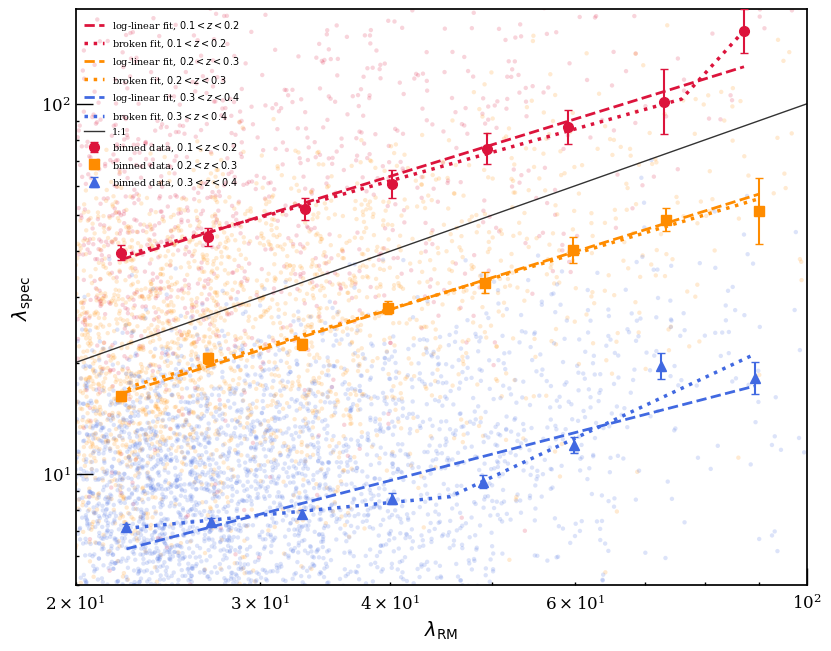

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import unique

# Assumes these already exist from the MCMC block:
# fit_data
# fit_results
# predict_model

table = bgs_matched

redmapper_col = "LAMBDA"
id_col = "ID"
z_col = "Z_SPEC_x"

z_bins = [[0.1, 0.2], [0.2, 0.3], [0.3, 0.4]]
z_colors = ["crimson", "darkorange", "royalblue"]
z_markers = ["o", "s", "^"]

rm_trend_bins = np.logspace(np.log10(20), np.log10(100), 9)

redmapper_values = np.asarray(table[redmapper_col], dtype=float)
z_values = np.asarray(table[z_col], dtype=float)

fig, ax = plt.subplots(figsize=(8.2, 6.4), constrained_layout=True)

# ------------------------------------------------------------
# Individual cluster scatter, color-coded by redshift bin
# ------------------------------------------------------------

cluster_table = unique(table, keys=id_col)
cluster_rm = np.asarray(cluster_table[redmapper_col], dtype=float)
cluster_z = np.asarray(cluster_table[z_col], dtype=float)
cluster_spec = np.asarray(cluster_table[LAMBDA_SPEC_COL], dtype=float)

for iz, ((zlo, zhi), color) in enumerate(zip(z_bins, z_colors)):
    good = (
        (cluster_z >= zlo)
        & (cluster_z < zhi)
        & np.isfinite(cluster_rm)
        & np.isfinite(cluster_spec)
        & (cluster_rm > 0)
        & (cluster_spec > 0)
    )

    ax.scatter(
        cluster_rm[good],
        cluster_spec[good],
        s=10,
        alpha=0.18,
        color=color,
        edgecolor="none",
        zorder=1,
    )


# ------------------------------------------------------------
# Binned data points and best-fit models
# ------------------------------------------------------------

for iz, ((zlo, zhi), color, marker) in enumerate(zip(z_bins, z_colors, z_markers)):
    zkey = (zlo, zhi)

    if zkey not in fit_data or zkey not in fit_results:
        continue

    data = fit_data[zkey]
    results = fit_results[zkey]

    x = np.asarray(data["x"], dtype=float)
    y = np.asarray(data["y"], dtype=float)
    yerr = np.asarray(data["yerr"], dtype=float)

    good = (
        np.isfinite(x)
        & np.isfinite(y)
        & np.isfinite(yerr)
        & (yerr > 0)
    )

    x_good = x[good]
    y_good = y[good]
    yerr_good = yerr[good]

    if len(x_good) == 0:
        continue

    y_linear = 10**y_good
    yerr_lower = y_linear - 10**(y_good - yerr_good)
    yerr_upper = 10**(y_good + yerr_good) - y_linear

    ax.errorbar(
        10**x_good,
        y_linear,
        yerr=[yerr_lower, yerr_upper],
        marker=marker,
        linestyle="none",
        capsize=3,
        color=color,
        ecolor=color,
        ms=7,
        label=rf"binned data, ${zlo}<z<{zhi}$",
        zorder=4,
    )

    xline = np.linspace(np.nanmin(x_good), np.nanmax(x_good), 300)

    if "loglinear" in results:
        loglin = results["loglinear"]
        yline_loglin = predict_model(
            loglin["best"],
            xline,
            "loglinear",
            loglin["x_pivot"],
        )

        ax.plot(
            10**xline,
            10**yline_loglin,
            linestyle="--",
            color=color,
            lw=2,
            label=rf"log-linear fit, ${zlo}<z<{zhi}$",
            zorder=5,
        )

    if "broken_loglinear" in results:
        broken = results["broken_loglinear"]
        yline_broken = predict_model(
            broken["best"],
            xline,
            "broken_loglinear",
            broken["x_pivot"],
        )

        ax.plot(
            10**xline,
            10**yline_broken,
            linestyle=":",
            color=color,
            lw=2.5,
            label=rf"broken fit, ${zlo}<z<{zhi}$",
            zorder=6,
        )


# ------------------------------------------------------------
# Reference line and formatting
# ------------------------------------------------------------

xline = np.linspace(20, 100, 300)
ax.plot(
    xline,
    xline,
    color="black",
    linestyle="-",
    lw=1,
    alpha=0.8,
    label="1:1",
    zorder=7,
)

ax.set_xlabel(r"$\lambda_{\rm RM}$")
ax.set_ylabel(r"$\lambda_{\rm spec}$")

ax.set_xlim(20, 100)
ax.set_ylim(5, 180)

ax.set_xscale('log')
ax.set_yscale('log')

ax.legend(frameon=False, fontsize=7, ncol=1, loc='upper left')
plt.savefig(plots_dir() + 'richness_scaling_fit.jpeg')
plt.show()


## Joint richness-redshift scaling relation

This section combines the three redshift slices into one data vector and fits a joint log-linear model. The baseline model contains only a richness slope, while the extended model adds a linear redshift-evolution term. A nonzero redshift coefficient quantifies residual evolution at fixed redMaPPer richness.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
from scipy.stats import chi2
from astropy.table import unique

# ------------------------------------------------------------
# 1. Build one combined binned data vector over lambda_RM and redshift
# ------------------------------------------------------------

redmapper_col = "LAMBDA"
id_col = "ID"
z_col = "Z_SPEC_x"
lambda_spec_col = LAMBDA_SPEC_COL

z_bins_joint = [(0.1, 0.2), (0.2, 0.3), (0.3, 0.4)]
rm_joint_bins = np.logspace(np.log10(20), np.log10(100), 9)

lambda_pivot_joint = 40.0
z_pivot_joint = 0.25

cluster_table_joint = unique(bgs_matched, keys=id_col)
lambda_rm_all = np.asarray(cluster_table_joint[redmapper_col], dtype=float)
z_all = np.asarray(cluster_table_joint[z_col], dtype=float)
lambda_spec_all = np.asarray(cluster_table_joint[lambda_spec_col], dtype=float)

joint_rows = []
for zlo, zhi in z_bins_joint:
    zmask = (z_all >= zlo) & (z_all < zhi)

    for lo, hi in zip(rm_joint_bins[:-1], rm_joint_bins[1:]):
        mask = (
            zmask
            & (lambda_rm_all >= lo)
            & (lambda_rm_all < hi)
            & np.isfinite(lambda_rm_all)
            & np.isfinite(z_all)
            & np.isfinite(lambda_spec_all)
            & (lambda_rm_all > 0)
            & (lambda_spec_all > 0)
        )

        if np.count_nonzero(mask) < 2:
            continue

        log_rm = np.log10(lambda_rm_all[mask])
        log_spec = np.log10(lambda_spec_all[mask])
        z_bin_values = z_all[mask]

        joint_rows.append({
            "zlo": zlo,
            "zhi": zhi,
            "rm_lo": lo,
            "rm_hi": hi,
            "x": np.nanmean(log_rm),
            "z": np.nanmean(z_bin_values),
            "y": np.nanmean(log_spec),
            "yerr": np.nanstd(log_spec, ddof=1) / np.sqrt(len(log_spec)),
            "n": len(log_spec),
        })

joint_x = np.asarray([row["x"] for row in joint_rows], dtype=float)
joint_z = np.asarray([row["z"] for row in joint_rows], dtype=float)
joint_y = np.asarray([row["y"] for row in joint_rows], dtype=float)
joint_yerr = np.asarray([row["yerr"] for row in joint_rows], dtype=float)
joint_n = np.asarray([row["n"] for row in joint_rows], dtype=int)

joint_good = (
    np.isfinite(joint_x)
    & np.isfinite(joint_z)
    & np.isfinite(joint_y)
    & np.isfinite(joint_yerr)
    & (joint_yerr > 0)
)

joint_x = joint_x[joint_good]
joint_z = joint_z[joint_good]
joint_y = joint_y[joint_good]
joint_yerr = joint_yerr[joint_good]
joint_n = joint_n[joint_good]
joint_rows = [row for row, keep in zip(joint_rows, joint_good) if keep]

print(f"Joint binned data points: {len(joint_x)}")
print(f"Total clusters in plotted bins: {np.sum(joint_n):,}")


# ------------------------------------------------------------
# 2. Define joint models
# ------------------------------------------------------------

def joint_noz_model(theta, x, z, x_pivot, z_pivot):
    alpha, beta, log_sigma_int = theta
    return alpha + beta * (x - x_pivot)


def joint_z_model(theta, x, z, x_pivot, z_pivot):
    alpha, beta, gamma, log_sigma_int = theta
    return alpha + beta * (x - x_pivot) + gamma * (z - z_pivot)


def joint_predict(theta, x, z, model_name, x_pivot, z_pivot):
    if model_name == "no_z":
        return joint_noz_model(theta, x, z, x_pivot, z_pivot)
    if model_name == "with_z":
        return joint_z_model(theta, x, z, x_pivot, z_pivot)
    raise ValueError(f"Unknown model_name: {model_name}")


def joint_log_prior(theta, model_name):
    if model_name == "no_z":
        alpha, beta, log_sigma_int = theta
        if not (0.0 < alpha < 3.0):
            return -np.inf
        if not (-5.0 < beta < 5.0):
            return -np.inf
        if not (-8.0 < log_sigma_int < 1.0):
            return -np.inf
        return 0.0

    if model_name == "with_z":
        alpha, beta, gamma, log_sigma_int = theta
        if not (0.0 < alpha < 3.0):
            return -np.inf
        if not (-5.0 < beta < 5.0):
            return -np.inf
        if not (-10.0 < gamma < 10.0):
            return -np.inf
        if not (-8.0 < log_sigma_int < 1.0):
            return -np.inf
        return 0.0

    raise ValueError(f"Unknown model_name: {model_name}")


def joint_log_likelihood(theta, x, z, y, yerr, model_name, x_pivot, z_pivot):
    y_model = joint_predict(theta, x, z, model_name, x_pivot, z_pivot)
    sigma_int = np.exp(theta[-1])
    sigma2 = yerr**2 + sigma_int**2
    return -0.5 * np.sum((y - y_model)**2 / sigma2 + np.log(2.0 * np.pi * sigma2))


def joint_log_probability(theta, x, z, y, yerr, model_name, x_pivot, z_pivot):
    lp = joint_log_prior(theta, model_name)
    if not np.isfinite(lp):
        return -np.inf
    return lp + joint_log_likelihood(theta, x, z, y, yerr, model_name, x_pivot, z_pivot)


def joint_initial_guess(x, z, y, yerr, model_name, x_pivot, z_pivot):
    good = np.isfinite(x) & np.isfinite(z) & np.isfinite(y) & np.isfinite(yerr) & (yerr > 0)

    if model_name == "no_z":
        coeff = np.polyfit(x[good] - x_pivot, y[good], deg=1)
        beta0, alpha0 = coeff[0], coeff[1]
        return np.asarray([alpha0, beta0, np.log(0.05)])

    if model_name == "with_z":
        design = np.vstack([
            np.ones(np.count_nonzero(good)),
            x[good] - x_pivot,
            z[good] - z_pivot,
        ]).T
        alpha0, beta0, gamma0 = np.linalg.lstsq(design, y[good], rcond=None)[0]
        return np.asarray([alpha0, beta0, gamma0, np.log(0.05)])

    raise ValueError(f"Unknown model_name: {model_name}")


def run_joint_mcmc_fit(
    x,
    z,
    y,
    yerr,
    model_name,
    x_pivot=np.log10(lambda_pivot_joint),
    z_pivot=z_pivot_joint,
    nwalkers=48,
    nsteps=6000,
    burn=1500,
    thin=10,
    random_seed=42,
):
    rng = np.random.default_rng(random_seed)
    p0_center = joint_initial_guess(x, z, y, yerr, model_name, x_pivot, z_pivot)
    ndim = len(p0_center)
    p0 = p0_center + 1e-3 * rng.normal(size=(nwalkers, ndim))

    sampler = emcee.EnsembleSampler(
        nwalkers,
        ndim,
        joint_log_probability,
        args=(x, z, y, yerr, model_name, x_pivot, z_pivot),
    )
    sampler.run_mcmc(p0, nsteps, progress=True)

    chain = sampler.get_chain(discard=burn, thin=thin, flat=True)
    log_prob = sampler.get_log_prob(discard=burn, thin=thin, flat=True)
    best = chain[np.argmax(log_prob)]
    percentiles = np.percentile(chain, [16, 50, 84], axis=0)

    stats = joint_fit_statistics(best, x, z, y, yerr, model_name, x_pivot, z_pivot)

    return {
        "model_name": model_name,
        "chain": chain,
        "log_prob": log_prob,
        "best": best,
        "percentiles": percentiles,
        "stats": stats,
        "x_pivot": x_pivot,
        "z_pivot": z_pivot,
    }


def joint_fit_statistics(theta, x, z, y, yerr, model_name, x_pivot, z_pivot):
    y_model = joint_predict(theta, x, z, model_name, x_pivot, z_pivot)
    sigma_int = np.exp(theta[-1])
    sigma2 = yerr**2 + sigma_int**2
    resid = y - y_model
    chi2_val = np.sum(resid**2 / sigma2)
    n = len(y)
    k = len(theta)
    dof = n - k
    loglike = joint_log_likelihood(theta, x, z, y, yerr, model_name, x_pivot, z_pivot)
    aic = 2 * k - 2 * loglike
    bic = k * np.log(n) - 2 * loglike

    return {
        "chi2": chi2_val,
        "dof": dof,
        "reduced_chi2": chi2_val / dof if dof > 0 else np.nan,
        "p_value": chi2.sf(chi2_val, dof) if dof > 0 else np.nan,
        "aic": aic,
        "bic": bic,
        "sigma_int_dex": sigma_int,
        "residual_mean_dex": np.nanmean(resid),
        "residual_std_dex": np.nanstd(resid, ddof=1),
    }


# ------------------------------------------------------------
# 3. Run MCMC fits
# ------------------------------------------------------------

joint_fit_results = {}

joint_fit_results["no_z"] = run_joint_mcmc_fit(
    joint_x,
    joint_z,
    joint_y,
    joint_yerr,
    "no_z",
    random_seed=11,
)

joint_fit_results["with_z"] = run_joint_mcmc_fit(
    joint_x,
    joint_z,
    joint_y,
    joint_yerr,
    "with_z",
    random_seed=12,
)


# ------------------------------------------------------------
# 4. Print summary
# ------------------------------------------------------------

joint_param_names = {
    "no_z": ["alpha", "slope", "log_sigma_int"],
    "with_z": ["alpha", "slope", "gamma_z", "log_sigma_int"],
}

for model_name, result in joint_fit_results.items():
    print("\n" + "=" * 72)
    print(f"Joint model: {model_name}")
    print("=" * 72)

    p16, p50, p84 = result["percentiles"]
    for name, lo, med, hi in zip(joint_param_names[model_name], p16, p50, p84):
        print(f"{name:16s} = {med:.4f} -{med - lo:.4f} +{hi - med:.4f}")

    print("Fit statistics:")
    for key, value in result["stats"].items():
        print(f"{key:20s}: {value:.4f}")

print("\n" + "=" * 72)
print("Joint model comparison")
print("=" * 72)
d_aic = joint_fit_results["with_z"]["stats"]["aic"] - joint_fit_results["no_z"]["stats"]["aic"]
d_bic = joint_fit_results["with_z"]["stats"]["bic"] - joint_fit_results["no_z"]["stats"]["bic"]
print(f"Delta AIC = AIC_with_z - AIC_no_z = {d_aic:.4f}")
print(f"Delta BIC = BIC_with_z - BIC_no_z = {d_bic:.4f}")
print("Negative Delta AIC/BIC means the redshift-evolution model is preferred.")


In [ ]:
# ------------------------------------------------------------
# Plot joint richness-redshift fit
# ------------------------------------------------------------

z_curve_values = [0.15, 0.25, 0.35]
z_curve_colors = ["tab:blue", "tab:orange", "tab:red"]

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.4), constrained_layout=True)
ax, rax = axes

# Individual clusters, lightly shown in the background.
good_cluster = (
    np.isfinite(lambda_rm_all)
    & np.isfinite(z_all)
    & np.isfinite(lambda_spec_all)
    & (lambda_rm_all > 0)
    & (lambda_spec_all > 0)
    & (z_all >= 0.1)
    & (z_all < 0.4)
)
sc = ax.scatter(
    lambda_rm_all[good_cluster],
    lambda_spec_all[good_cluster],
    c=z_all[good_cluster],
    s=8,
    alpha=0.18,
    cmap="viridis",
    edgecolor="none",
    rasterized=True,
    label="clusters",
)

# Binned data vector.
for (zlo, zhi), color in zip(z_bins_joint, z_curve_colors):
    row_mask = np.asarray([(row["zlo"] == zlo and row["zhi"] == zhi) for row in joint_rows])
    x = joint_x[row_mask]
    y = joint_y[row_mask]
    yerr = joint_yerr[row_mask]

    y_linear = 10**y
    yerr_lower = y_linear - 10**(y - yerr)
    yerr_upper = 10**(y + yerr) - y_linear

    ax.errorbar(
        10**x,
        y_linear,
        yerr=[yerr_lower, yerr_upper],
        fmt="o",
        color=color,
        ecolor=color,
        capsize=0,
        ms=6,
        linestyle="none",
        label=rf"binned, ${zlo}<z<{zhi}$",
        zorder=5,
    )

# Best-fit redshift-evolution curves.
xline_linear = np.logspace(np.log10(20), np.log10(100), 300)
xline = np.log10(xline_linear)
with_z_result = joint_fit_results["with_z"]
no_z_result = joint_fit_results["no_z"]

for z_value, color in zip(z_curve_values, z_curve_colors):
    zline = np.full_like(xline, z_value)
    yline = joint_predict(
        with_z_result["best"],
        xline,
        zline,
        "with_z",
        with_z_result["x_pivot"],
        with_z_result["z_pivot"],
    )
    ax.plot(
        xline_linear,
        10**yline,
        color=color,
        lw=2.2,
        label=rf"with-z fit, $z={z_value:.2f}$",
        zorder=6,
    )

# No-z model as a black dashed reference.
yline_noz = joint_predict(
    no_z_result["best"],
    xline,
    np.full_like(xline, z_pivot_joint),
    "no_z",
    no_z_result["x_pivot"],
    no_z_result["z_pivot"],
)
ax.plot(xline_linear, 10**yline_noz, color="black", lw=2.0, ls="--", label="no-z fit")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(20, 100)
ax.set_ylim(5, 300)
ax.set_xlabel(r"$\lambda_{\rm RM}$")
ax.set_ylabel(r"$\lambda_{\rm spec}$")
ax.legend(frameon=False, fontsize=8, loc="upper left")
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r"$z_{\rm spec,BCG}$")

# Residuals versus redshift for the with-z model.
y_model_joint = joint_predict(
    with_z_result["best"],
    joint_x,
    joint_z,
    "with_z",
    with_z_result["x_pivot"],
    with_z_result["z_pivot"],
)
resid_joint = joint_y - y_model_joint

for (zlo, zhi), color in zip(z_bins_joint, z_curve_colors):
    row_mask = np.asarray([(row["zlo"] == zlo and row["zhi"] == zhi) for row in joint_rows])
    rax.errorbar(
        joint_z[row_mask],
        resid_joint[row_mask],
        yerr=joint_yerr[row_mask],
        fmt="o",
        color=color,
        ecolor=color,
        capsize=0,
        linestyle="none",
        label=rf"${zlo}<z<{zhi}$",
    )

rax.axhline(0.0, color="black", lw=1.0, ls="--")
rax.set_xlabel(r"$z_{\rm spec,BCG}$")
rax.set_ylabel(r"$\Delta\log_{10}\lambda_{\rm spec}$")
rax.legend(frameon=False, fontsize=8, loc="best")

for axis in axes:
    axis.tick_params(direction="in", top=True, right=True)
    for spine in axis.spines.values():
        spine.set_linewidth(1.1)

plt.savefig(plots_dir() + "richness_joint_loglinear_redshift_fit.jpeg", dpi=180)
plt.show()


In [ ]:
## Compare with other trends

## Save precomputed LF-weighted lambda_spec into the local-overdensity cluster table

This cell reads the LF-weighted spectroscopic richness that is already stored in the matched catalog, collapses to one row per cluster, and joins those values onto the DR9 local-overdensity table by `ID`. It does not recompute `lambda_spec` in this notebook.


In [ ]:
from pathlib import Path
from astropy.table import Table, join, unique
import numpy as np

repo_root = Path.cwd()
if repo_root.name == "richness_relation":
    repo_root = repo_root.parent

local_overdensity_path = repo_root / "local_overdensity" / "dr9_one_file_outputs" / "rm_dr9_local_overdensity_sweep.fits"
output_fits = repo_root / "local_overdensity" / "dr9_one_file_outputs" / "rm_dr9_local_overdensity_sweep_with_lambda_spec_lfweighted.fits"
output_ecsv = repo_root / "local_overdensity" / "dr9_one_file_outputs" / "rm_dr9_local_overdensity_sweep_with_lambda_spec_lfweighted.ecsv"

cluster_table = unique(bgs_matched, keys="ID")

lambda_spec_table = Table()
lambda_spec_table["ID"] = np.asarray(cluster_table["ID"], dtype=int)
lambda_spec_table["lambda_spec"] = np.asarray(cluster_table[LAMBDA_SPEC_COL], dtype=float)
lambda_spec_table["lambda_true"] = np.asarray(cluster_table[LAMBDA_SPEC_COL], dtype=float)
lambda_spec_table["lambda_spec_tot"] = np.asarray(cluster_table[LAMBDA_SPEC_TOT_COL], dtype=float)
lambda_spec_table["lambda_spec_lfweighted"] = np.asarray(cluster_table[LAMBDA_SPEC_COL], dtype=float)
lambda_spec_table["lambda_spec_noproj_weighted"] = np.asarray(cluster_table[LAMBDA_SPEC_COL], dtype=float)
lambda_spec_table["lambda_spec_tot_lfweighted"] = np.asarray(cluster_table[LAMBDA_SPEC_TOT_COL], dtype=float)

rm_overdensity = Table.read(local_overdensity_path)
for col in [
    "lambda_spec",
    "lambda_true",
    "lambda_spec_tot",
    "lambda_spec_lfweighted",
    "lambda_spec_noproj_weighted",
    "lambda_spec_tot_lfweighted",
]:
    if col in rm_overdensity.colnames:
        rm_overdensity.remove_column(col)

rm_overdensity_with_spec = join(
    rm_overdensity,
    lambda_spec_table,
    keys="ID",
    join_type="left",
    metadata_conflicts="silent",
)

rm_overdensity_with_spec.write(output_fits, overwrite=True)
rm_overdensity_with_spec.write(output_ecsv, format="ascii.ecsv", overwrite=True)

print(f"Wrote {output_fits}")
print(f"Wrote {output_ecsv}")
print(f"Rows: {len(rm_overdensity_with_spec):,}")
lambda_col = rm_overdensity_with_spec["lambda_spec"]
if hasattr(lambda_col, "mask"):
    n_with_lambda = np.count_nonzero(~lambda_col.mask)
else:
    n_with_lambda = np.count_nonzero(np.isfinite(np.asarray(lambda_col, dtype=float)))
print(f"Clusters with precomputed LF-weighted lambda_spec: {n_with_lambda:,}")
